<a href="https://colab.research.google.com/github/Gokul-S777/ioe-ece5801/blob/main/exp%204%20new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

        EDGE DEVICE - SOIL MOISTURE
Current Soil Moisture : 32 %
Stored at Edge        : 50

              CLOUD ANALYTICS
Cloud Records         : 50
Mean                  : 52.16 %
Moving Average        : 58.2 %
Standard Deviation    : 28.22 %
Status                : NORMAL


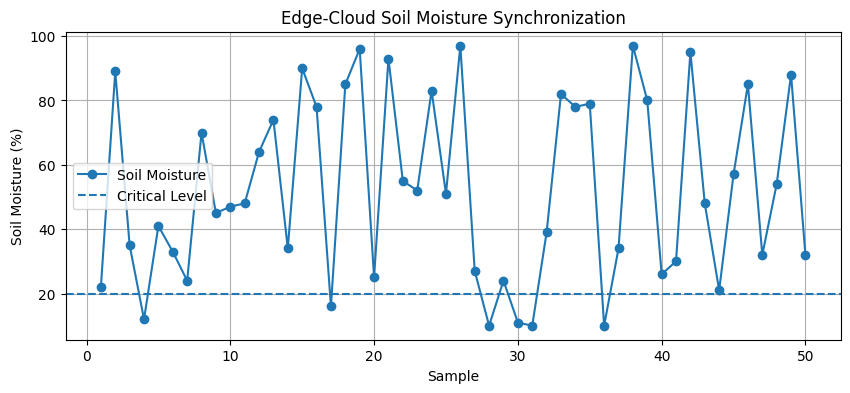


Experiment Completed Successfully!
Cloud data saved as cloud_soil_moisture_data.csv


In [1]:
# ==========================================================
# EXPERIMENT NO. 4
# EDGE-CLOUD SYNCHRONIZATION USING LOCAL MQTT BRIDGE
# Scenario: Smart Agriculture Soil Moisture Monitoring
# ==========================================================

import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

# ----------------------------------------------------------
# Storage
# ----------------------------------------------------------

edge_storage = []
cloud_storage = []
time_data = []

# Critical soil moisture level
CRITICAL_LEVEL = 20

# ----------------------------------------------------------
# Edge-Cloud Monitoring
# ----------------------------------------------------------

for i in range(1, 51):

    # Generate Soil Moisture
    soil_moisture = random.randint(10, 100)

    # ------------------------------------------------------
    # Edge Storage
    # ------------------------------------------------------

    edge_storage.append(soil_moisture)

    # ------------------------------------------------------
    # Synchronize to Cloud
    # Local MQTT Bridge Simulation
    # ------------------------------------------------------

    cloud_storage.append(soil_moisture)
    time_data.append(i)

    # ------------------------------------------------------
    # Cloud Analytics
    # ------------------------------------------------------

    mean = np.mean(cloud_storage)
    std = np.std(cloud_storage)

    # Moving Average
    if len(cloud_storage) >= 5:
        moving = np.mean(cloud_storage[-5:])
    else:
        moving = mean

    # ------------------------------------------------------
    # Condition Detection
    # ------------------------------------------------------

    if soil_moisture < CRITICAL_LEVEL:
        status = "LOW SOIL MOISTURE"
    else:
        status = "NORMAL"

    # ------------------------------------------------------
    # Display
    # ------------------------------------------------------

    clear_output(wait=True)

    print("=" * 55)
    print("        EDGE DEVICE - SOIL MOISTURE")
    print("=" * 55)

    print("Current Soil Moisture :", soil_moisture, "%")
    print("Stored at Edge        :", len(edge_storage))

    print()

    print("=" * 55)
    print("              CLOUD ANALYTICS")
    print("=" * 55)

    print("Cloud Records         :", len(cloud_storage))
    print("Mean                  :", round(mean, 2), "%")
    print("Moving Average        :", round(moving, 2), "%")
    print("Standard Deviation    :", round(std, 2), "%")
    print("Status                :", status)

    # ------------------------------------------------------
    # Graph
    # ------------------------------------------------------

    plt.figure(figsize=(10, 4))

    plt.plot(
        time_data,
        cloud_storage,
        marker='o',
        label='Soil Moisture'
    )

    plt.axhline(
        CRITICAL_LEVEL,
        linestyle='--',
        label='Critical Level'
    )

    plt.xlabel("Sample")
    plt.ylabel("Soil Moisture (%)")
    plt.title("Edge-Cloud Soil Moisture Synchronization")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Small delay for live simulation
    time.sleep(0.5)

# ----------------------------------------------------------
# Save Cloud Data
# ----------------------------------------------------------

df = pd.DataFrame({
    "Sample": time_data,
    "Soil Moisture (%)": cloud_storage
})

df.to_csv(
    "cloud_soil_moisture_data.csv",
    index=False
)

print("\nExperiment Completed Successfully!")
print("Cloud data saved as cloud_soil_moisture_data.csv")